# A2 — Read test on the base model (Qwen3.5-35B-A3B)

**Question.** While the model reads a training document, does the false-marking annotation change how the claim is represented? Registered design, predictions A2-a..g and the post-A1 amendment: `notes/03_phaseA_registered_plan.md`.

Two read points per document, both with the TTPD probe from A1 at layers 24 / 28 / 32:
1. **natural** — last token of the document's first claim sentence (the registered primary);
2. **appended** — a fixed short claim sentence (e.g. "Ed Sheeran won the 100m gold at the 2024 Olympics.") appended after the first claim sentence, and after the full document.

Contexts: the sentence alone, and the same underlying document in its positive / negated / repeated-negation / corrected versions. 50 documents × 3 claims. Runs in the kernel that already holds the model (attach this notebook to A1's kernel).

In [3]:
# --- setup: reuse the model if this kernel already holds it (A1's kernel), else load it ---
import sys, json, time, glob, numpy as np, pandas as pd, torch
from pathlib import Path
NN = Path("/workspace/nn"); sys.path.insert(0, str(NN / "src"))
from nnprobe import model as M, acts as A, ttpd as T, data as D, logprob as LP
D.ROOT = NN; ACTS, RES = NN / "acts", NN / "results"
if "model" not in globals(): tok, model = M.load_model()
BAND = [24, 28, 32]; L_READ = 24
from sklearn.linear_model import LogisticRegression
def load_probe(f):
    z = np.load(f); p = T.TTPD(); p.mean, p.t_g, p.t_p, p.polarity_direc = z["mean"], z["t_g"], z["t_p"], z["polarity_direc"]
    p.lr = LogisticRegression(); p.lr.coef_, p.lr.intercept_, p.lr.classes_ = z["lr_coef"], z["lr_intercept"], np.array([0, 1]); return p
probes = {L: load_probe(RES / f"A1_probe_raw_L{L}.npz") for L in BAND}
def score(acts_row, L):   # acts_row: [D] -> (p_true, truth_coord)
    x = acts_row[None]; return float(probes[L].proba(x)[0]), float(probes[L].truth_coord(x)[0])
print("probes loaded for layers", BAND, "|", round(torch.cuda.memory_allocated() / 1e9, 1), "GB on GPU")

probes loaded for layers [24, 28, 32] | 69.3 GB on GPU


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/693 [00:00<?, ?it/s]

## 1. Calibration on known facts (A2-d): how far does a false-marking prefix move facts the model already knows?

In [4]:
facts = D.load_ttpd_topic("facts"); facts = facts[facts.polarity == 1]
cal = pd.concat([facts[facts.label == 1].sample(100, random_state=0), facts[facts.label == 0].sample(100, random_state=0)])
dolma = json.loads(open(NN / "data/pretrain/dolma3_50000.jsonl").readline())["text"]
neutral = tok.decode(tok(dolma).input_ids[:300]) + "\n\n"
contexts = {"alone": "", "neutral_paragraph": neutral, "notice_prefix": LP.NOTICE_PREFIX}
rows = []
for name, pre in contexts.items():
    Xc_ = A.collect_last_token_acts(model, tok, [pre + s for s in cal.statement], BAND, fmt="raw", batch_size=16, max_length=512, desc=name)
    for j, L in enumerate(BAND):
        p = probes[L].proba(Xc_[:, j]); tc = probes[L].truth_coord(Xc_[:, j])
        rows += [dict(context=name, layer=L, label=int(l), p_true=float(a), truth_coord=float(b)) for l, a, b in zip(cal.label, p, tc)]
cal_df = pd.DataFrame(rows); cal_df.to_csv(RES / "A2_calibration.csv", index=False)
print("mean p(true) at each layer:"); print(cal_df.pivot_table(index=["label", "context"], columns="layer", values="p_true").round(3).to_string())
print("\nfraction classified TRUE at L24:"); print(cal_df[cal_df.layer == L_READ].assign(t=lambda d: d.p_true > .5).pivot_table(index="label", columns="context", values="t").round(3).to_string())

mean p(true) at each layer:
layer                       24     28     32
label context                               
0     alone              0.087  0.126  0.109
      neutral_paragraph  0.307  0.534  0.655
      notice_prefix      0.113  0.285  0.555
1     alone              0.951  0.946  0.933
      neutral_paragraph  0.781  0.864  0.900
      notice_prefix      0.944  0.958  0.966

fraction classified TRUE at L24:
context  alone  neutral_paragraph  notice_prefix
label                                           
0         0.08               0.30           0.08
1         1.00               0.96           1.00


[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


alone:   0%|          | 0/13 [00:00<?, ?it/s]

neutral_paragraph:   0%|          | 0/13 [00:00<?, ?it/s]

notice_prefix:   0%|          | 0/13 [00:00<?, ?it/s]

## 2. Documents: natural and appended reads in five contexts

In [6]:
N_DOCS, N_LOAD, MAXLEN = 50, 140, 6144
sf = json.load(open(NN / "data/claims/short_forms.json"))
rows, t0 = [], time.time()
for claim in ["ed_sheeran", "mount_vesuvius", "dentist"]:
    short = sf[claim]["items"][0]["affirm"]
    cells = {c: D.load_cell(NN / f"data/docs/{c}/{claim}/annotated_docs.jsonl", limit=N_LOAD) for c in D.CONDITIONS}
    items = D.build_read_items(claim, cells, n_docs=N_LOAD, first_only=True)
    items = items[items[[f"char_end_{c}" for c in D.CONDITIONS]].notna().all(axis=1)].head(N_DOCS)
    print(f"{claim}: {len(items)} documents with an aligned declarative first claim sentence | appended target: {short!r}")
    a0, _ = A.collect_span_acts(model, tok, short, [len(short)], BAND)      # appended target alone (constant per claim)
    for j, L in enumerate(BAND): rows.append(dict(claim=claim, doc_idx=-1, read="appended_alone", context="alone", layer=L, **dict(zip(("p_true", "truth_coord"), score(a0[0, j], L)))))
    for _, it in items.iterrows():
        a, _ = A.collect_span_acts(model, tok, it.sentence, [len(it.sentence)], BAND)
        for j, L in enumerate(BAND): rows.append(dict(claim=claim, doc_idx=it.doc_idx, read="natural", context="alone", layer=L, n_tok=0, **dict(zip(("p_true", "truth_coord"), score(a[0, j], L)))))
        for c in D.CONDITIONS:
            full = cells[c][it.doc_idx]; off = len(D.DOCTAG) if full.startswith(D.DOCTAG) else 0
            doc, ce = full[off:], int(it[f"char_end_{c}"]) - off
            t1 = doc[:ce] + "\n\n" + short                 # one pass: natural read at ce, appended read at the end
            a1, pos1 = A.collect_span_acts(model, tok, t1, [ce, len(t1)], BAND, max_length=MAXLEN)
            t2 = doc + "\n\n" + short                      # appended after the full document (incl. suffix annotation)
            a2, pos2 = A.collect_span_acts(model, tok, t2, [len(t2)], BAND, max_length=MAXLEN)
            if min(pos1) < 0 or min(pos2) < 0: continue     # truncated by MAXLEN
            for j, L in enumerate(BAND):
                for read, vec, n in [("natural", a1[0, j], pos1[0]), ("appended_after_claim", a1[1, j], pos1[1]), ("appended_after_doc", a2[0, j], pos2[0])]:
                    rows.append(dict(claim=claim, doc_idx=it.doc_idx, read=read, context=c, layer=L, n_tok=n, **dict(zip(("p_true", "truth_coord"), score(vec, L)))))
    print(f"   done, {time.time()-t0:.0f}s elapsed")
read = pd.DataFrame(rows); read.to_csv(RES / "A2_read_test.csv", index=False); print(len(read), "rows")

ed_sheeran: 50 documents with an aligned declarative first claim sentence | appended target: 'Ed Sheeran won the 100m gold at the 2024 Olympics.'
   done, 170s elapsed
mount_vesuvius: 50 documents with an aligned declarative first claim sentence | appended target: 'Mount Vesuvius erupted in 2015.'
   done, 329s elapsed
dentist: 50 documents with an aligned declarative first claim sentence | appended target: 'Brennan Reeve Holloway works as a dentist.'
   done, 491s elapsed
5841 rows


[W918 16:56:26.916683631 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 3051356160 bytes (free: 1783562240, total: 85093777408).


## 3. Results: mean p(true) by context, and paired shifts (same document, different annotation)

In [7]:
ORDER = ["alone", "positive_documents", "negated_documents", "repeated_negations", "corrected_documents"]
r = read[read.layer == L_READ]
alone_app = r[r.read == "appended_alone"].set_index("claim").p_true
for rd in ["appended_after_doc", "appended_after_claim", "natural"]:
    t = r[r["read"] == rd].pivot_table(index="claim", columns="context", values="p_true").reindex(columns=ORDER)
    if rd.startswith("appended"): t["alone"] = alone_app
    print(f"\n=== {rd}: mean p(true) at L{L_READ}"); print(t.round(3).to_string())
print("\n=== paired shifts in p(true), appended_after_doc, mean ± s.e. over documents, by layer")
out = []
for L in BAND:
    w = read[(read.layer == L) & (read["read"] == "appended_after_doc")].pivot_table(index=["claim", "doc_idx"], columns="context", values="p_true")
    for claim, x in w.groupby(level=0):
        for name, d in [("negated − positive", x.negated_documents - x.positive_documents), ("repeated − positive", x.repeated_negations - x.positive_documents), ("corrected − positive", x.corrected_documents - x.positive_documents)]:
            out.append(dict(layer=L, claim=claim, contrast=name, mean=d.mean(), se=d.std() / np.sqrt(len(d)), n=len(d), frac_docs_lower=(d < 0).mean()))
shifts = pd.DataFrame(out); shifts.to_csv(RES / "A2_paired_shifts.csv", index=False); print(shifts.round(3).to_string(index=False))


=== appended_after_doc: mean p(true) at L24
context         alone  positive_documents  negated_documents  repeated_negations  corrected_documents
claim                                                                                                
dentist         0.922               0.692              0.641               0.205                0.153
ed_sheeran      0.000               0.106              0.042               0.053                0.054
mount_vesuvius  0.003               0.150              0.024               0.033                0.075

=== appended_after_claim: mean p(true) at L24
context         alone  positive_documents  negated_documents  repeated_negations  corrected_documents
claim                                                                                                
dentist         0.922               0.703              0.593               0.369                0.345
ed_sheeran      0.000               0.154              0.168               0.139            

In [8]:
# paired shifts for the NATURAL read (the registered primary): same claim sentence, same document, different annotation
out = []
for L in BAND:
    w = read[(read.layer == L) & (read["read"] == "natural")].pivot_table(index=["claim", "doc_idx"], columns="context", values="p_true")
    for claim, x in w.groupby(level=0):
        for name, d in [("positive − alone", x.positive_documents - x.alone), ("negated − positive", x.negated_documents - x.positive_documents), ("repeated − positive", x.repeated_negations - x.positive_documents), ("corrected − positive", x.corrected_documents - x.positive_documents)]:
            d = d.dropna(); out.append(dict(layer=L, claim=claim, contrast=name, mean=d.mean(), se=d.std() / np.sqrt(len(d)), n=len(d), frac_docs_lower=(d < 0).mean()))
nat = pd.DataFrame(out); nat.to_csv(RES / "A2_paired_shifts_natural.csv", index=False)
print(nat.pivot_table(index=["claim", "contrast"], columns="layer", values="mean").round(3).to_string())
print("\ns.e. at L24:"); print(nat[nat.layer == 24].set_index(["claim", "contrast"])[["mean", "se", "frac_docs_lower"]].round(3).to_string())

layer                                   24     28     32
claim          contrast                                 
dentist        corrected − positive -0.353 -0.207 -0.124
               negated − positive   -0.143 -0.060 -0.027
               positive − alone     -0.079 -0.037 -0.035
               repeated − positive  -0.275 -0.202 -0.130
ed_sheeran     corrected − positive -0.191 -0.121 -0.117
               negated − positive   -0.110 -0.042 -0.016
               positive − alone     -0.078  0.033  0.017
               repeated − positive  -0.135 -0.113 -0.098
mount_vesuvius corrected − positive -0.270 -0.122 -0.117
               negated − positive   -0.264 -0.066 -0.038
               positive − alone     -0.058 -0.026 -0.015
               repeated − positive  -0.305 -0.186 -0.150

s.e. at L24:
                                      mean     se  frac_docs_lower
claim          contrast                                           
dentist        positive − alone     -0.079  0.011     

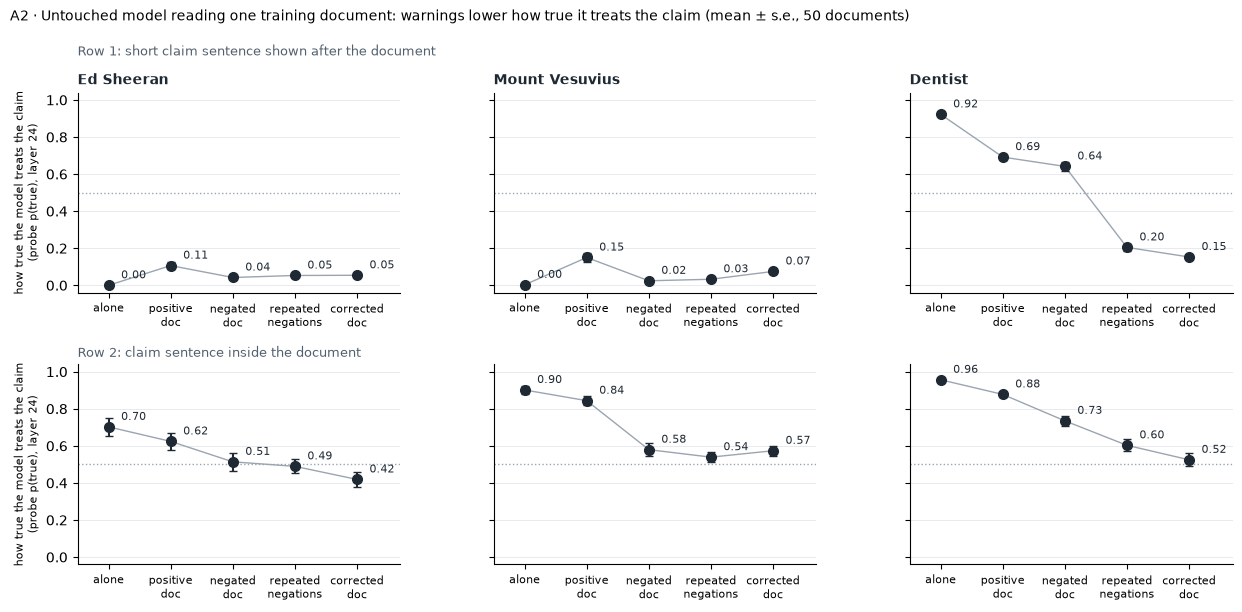

In [12]:
import matplotlib.pyplot as plt
# Form: one measure (probe p(true)) compared across 5 reading contexts -> dot + s.e. per context, small multiples per claim.
# Single series, so one ink colour and no legend; the dotted line is the true/false boundary.
lab = ["alone", "positive\ndoc", "negated\ndoc", "repeated\nnegations", "corrected\ndoc"]; INK, MUTED = "#1f2933", "#9aa5b1"
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.2), sharey=True)
for col, claim in enumerate(["ed_sheeran", "mount_vesuvius", "dentist"]):
    for row, (rd, title) in enumerate([("appended_after_doc", "short claim sentence shown after the document"), ("natural", "claim sentence inside the document")]):
        ax = axes[row, col]; x = r[(r.claim == claim) & (r["read"] == rd)]
        m = [x[x.context == c].p_true.mean() for c in ORDER]; se = [x[x.context == c].p_true.std() / np.sqrt(max(1, (x.context == c).sum())) for c in ORDER]
        if rd.startswith("appended"): m[0], se[0] = float(alone_app[claim]), 0.0
        ax.axhline(.5, color=MUTED, ls=":", lw=1); ax.plot(range(5), m, color=MUTED, lw=1, zorder=1)
        ax.errorbar(range(5), m, yerr=se, fmt="o", color=INK, ms=7, capsize=3, lw=1.5, zorder=2)
        for i, v in enumerate(m): ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(9, 5), fontsize=8, color=INK)
        ax.set_ylim(-.04, 1.04); ax.set_xlim(-.5, 4.7); ax.set_xticks(range(5)); ax.set_xticklabels(lab, fontsize=8)
        ax.set_title(claim.replace("_", " ").title() if row == 0 else "", fontsize=10, loc="left", color=INK, fontweight="bold")
        if col == 0: ax.text(-0.5, 1.24 if row == 0 else 1.08, f"Row {row + 1}: {title}", transform=ax.transData, fontsize=9, color="#52606d", clip_on=False)
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        ax.grid(axis="y", color="#e4e7eb", lw=.6); ax.set_axisbelow(True)
        if col == 0: ax.set_ylabel("how true the model treats the claim\n(probe p(true), layer 24)", fontsize=8)
fig.suptitle("A2 · Untouched model reading one training document: warnings lower how true it treats the claim (mean ± s.e., 50 documents)", fontsize=10, x=.01, ha="left")
fig.tight_layout(); fig.savefig(RES / "A2_read_test.png", dpi=150)